# **🧪 Experimentación y Modelado**

Registro de los experimentos del modelo final. Cada configuración se evalúa con la misma **CV estratificada de 5 folds** del baseline y se registra en **MLflow** (parámetros, métricas, lista de features y curva de ganancia). La lógica vive en `src/` y este notebook solo orquesta los experimentos.

Orden de los experimentos:

1. **Baseline replicado**, como referencia.
2. **Conjuntos de features** del notebook 03 con LightGBM por defecto.
3. **Otros modelos** con el mejor conjunto de features.
4. **Búsqueda de hiperparámetros** del mejor modelo con Optuna.
5. **Validación del tuning con folds nuevos**, calibración y umbral.
6. **Entrenamiento sensible al monto**, con pesos por transacción.
7. **Variables de poco aporte**: qué pasa al quitarlas.
8. **Modelo final y umbral**, validado como pipeline productivo.
9. **Validación out-of-time**: el modelo final prediciendo semanas futuras.
10. **Umbral por monto y por país**, frente al umbral único.

La métrica principal sigue siendo el **% de la ganancia máxima** (+25% del monto por legítima aprobada, −100% por fraude aprobado), con el umbral que maximiza la ganancia out-of-fold. Como todos los experimentos usan los mismos folds, se comparan **fold a fold** contra el baseline.

Para explorar los runs: `mlflow ui --backend-store-uri sqlite:///mlflow.db` desde la raíz del proyecto.

## **📚 Librerías**

In [1]:
# Librerías para manipulación de datos
import warnings

import pandas as pd
import numpy as np

# Registro de experimentos y búsqueda de hiperparámetros
import mlflow
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Calibración de probabilidades
from sklearn.calibration import calibration_curve

# Mostrar varias tablas en una misma celda
from IPython.display import display

# Librerías de visualización
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Módulos del proyecto: features, validación y registro en MLflow
from fraude_shipping.experimentation.candidate_features import build_features
from fraude_shipping.experimentation.tracking import run_experiment
from fraude_shipping.features import ORIGINAL_COLUMNS, SEED, load_data, make_folds
from fraude_shipping.production.pipeline import THRESHOLD, FraudPipeline
from fraude_shipping.profit import PROFIT_MARGIN, compute_profit, optimal_threshold, profit_curve
from fraude_shipping.registry import DESCRIPTION_TAG, setup_mlflow

c:\Users\jmart\Documents\Proyectos\Data_Science\06_Proyectos\fraude_shipping\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Gráficos interactivos en el editor y PNG estático para GitHub y el informe
pio.renderers.default = 'plotly_mimetype+png'
pio.templates.default = 'plotly_white'

COLOR_PRINCIPAL = '#2a78d6'
COLOR_REFERENCIA = '#898781'
NOMBRE_EXPERIMENTO = 'fraude_shipping'

# Búsqueda de hiperparámetros: número de pruebas y semilla de los folds nuevos para validar el resultado
NUMERO_PRUEBAS = 50
SEMILLA_VALIDACION = 7

# Validación out-of-time: inicio de cada semana evaluada y remuestras del bootstrap del umbral
SEMANAS_EVALUADAS = ['2020-04-01', '2020-04-08', '2020-04-15']
REMUESTRAS_BOOTSTRAP = 500
# Tramos de monto para la calibración y el umbral por monto
TRAMOS_MONTO = [0, 100, 300, np.inf]
ETIQUETAS_TRAMOS = ['< 100', '100–300', '≥ 300']

optuna.logging.set_verbosity(optuna.logging.WARNING)
# MLflow avisa en cada run que infiere los tipos del dataset registrado; no afecta los resultados
warnings.filterwarnings('ignore', module='mlflow.types.utils')

In [ ]:
# Descripción de cada run en MLflow: se ve en la UI de experimentos y en el detalle de cada run
DESCRIPCIONES_RUNS = {
    'baseline': 'LightGBM por defecto con las variables originales: la referencia de todos los experimentos.',
    'mas_perfil_onp': 'Baseline más perfil_onp, la combinación de o, n y p.',
    'mas_hora': 'Baseline más la hora del día.',
    'g_agrupado': 'Baseline con g reemplazada por el país agrupado (países con menos de 100 transacciones pasan a Otros).',
    'sin_j': 'Baseline sin la variable j cruda.',
    'j_tasa_frecuencia': 'j reemplazada por su tasa de fraude, calculada sin la etiqueta de la propia fila, y su frecuencia.',
    'j_cruda_mas_tasa': 'j cruda más su tasa de fraude y su frecuencia.',
    'candidatas': 'Conjunto elegido: originales sin g ni j, más g_agrupado, perfil_onp, hora y frecuencia y tasa de fraude de j.',
    'candidatas_sin_k': 'Conjunto candidatas sin k, que no mostró señal.',
    'todas': 'Todas las variables originales y las 18 candidatas del notebook 03.',
    'todas_sin_j_cruda': 'Todas las variables, con j solo como tasa y frecuencia.',
    'candidatas_xgboost': 'XGBoost con parámetros por defecto y el conjunto candidatas.',
    'candidatas_catboost': 'CatBoost con parámetros por defecto y el conjunto candidatas.',
    'candidatas_random_forest': 'Random Forest con parámetros por defecto y el conjunto candidatas.',
    'candidatas_regresion_logistica': 'Regresión logística (imputación, normalización y one-hot) con el conjunto candidatas.',
    'optuna_lightgbm': 'Búsqueda bayesiana de hiperparámetros de LightGBM: 50 pruebas anidadas sobre los folds del baseline.',
    'validacion_lightgbm_defecto': 'LightGBM por defecto con folds nuevos (semilla 7): la referencia para medir el tuning.',
    'validacion_lightgbm_tuneado': 'LightGBM con los hiperparámetros de Optuna, evaluado con folds nuevos que no participaron en la búsqueda.',
    'validacion_lightgbm_tuneado_peso_raiz_monto': 'LightGBM tuneado entrenado con pesos proporcionales a la raíz del monto.',
    'validacion_lightgbm_tuneado_peso_monto': 'LightGBM tuneado entrenado con pesos proporcionales al monto.',
    'validacion_lightgbm_tuneado_sin_hora': 'LightGBM tuneado sin la variable hora, para medir su aporte.',
    'validacion_lightgbm_tuneado_sin_perfil_onp': 'Modelo final: LightGBM tuneado sin perfil_onp (19 variables). Es el run que explica el notebook 05.',
    'optuna_lightgbm_pasado': 'Búsqueda de Optuna repetida solo con datos previos al 15/04, para evaluar la última semana sin contaminación.',
    'validacion_lightgbm_tuneado_pasado': 'Hiperparámetros elegidos solo con el pasado, validados con los datos previos al 15/04; sus predicciones eligen los umbrales por segmento.',
}

In [3]:
# Compara cada experimento contra el de referencia, fold a fold, sobre los mismos folds


def comparar_experimentos(resultados, referencia):
    """Tabla con las métricas medias de cada experimento, la diferencia en ganancia y en cuántos folds supera a la referencia."""
    ganancia_referencia = resultados[referencia].fold_metrics['ganancia_pct_maxima']
    filas = []
    for nombre, resultado in resultados.items():
        ganancia = resultado.fold_metrics['ganancia_pct_maxima']
        filas.append({
            'experimento': nombre,
            'ganancia_pct_maxima': ganancia.mean(),
            'desvio': ganancia.std(),
            'diferencia_vs_referencia': (ganancia - ganancia_referencia).mean(),
            'folds_mejores': int((ganancia > ganancia_referencia).sum()),
            'auc_roc': resultado.fold_metrics['auc_roc'].mean(),
            'auc_pr': resultado.fold_metrics['auc_pr'].mean(),
            'umbral': resultado.threshold,
        })
    return pd.DataFrame(filas).set_index('experimento').round(3)


def ganancia_pct_maxima(fraude, monto, probabilidad, umbral):
    """Ganancia de aprobar si la probabilidad es menor al umbral, en % de la ganancia máxima."""
    ganancia_maxima = compute_profit(fraude, monto, fraude == 0)
    return compute_profit(fraude, monto, probabilidad < umbral) / ganancia_maxima * 100


def calibracion_por_monto(datos_modelo, probabilidad, umbral_inferior, umbral_superior):
    """Predicho y observado en una franja de probabilidad, por conteo y ponderados por monto, total y por tramo de monto."""
    franja = datos_modelo.assign(probabilidad=probabilidad).query('@umbral_inferior <= probabilidad < @umbral_superior')
    tramo = pd.cut(franja['monto'], TRAMOS_MONTO, right=False, labels=ETIQUETAS_TRAMOS)

    def resumen(grupo):
        return pd.Series({
            'transacciones': len(grupo),
            'predicho': grupo['probabilidad'].mean(),
            'observado': grupo['fraude'].mean(),
            'predicho_por_monto': np.average(grupo['probabilidad'], weights=grupo['monto']),
            'observado_por_monto': np.average(grupo['fraude'], weights=grupo['monto']),
        })

    return pd.concat([resumen(franja).to_frame('franja completa').T, franja.groupby(tramo, observed=True).apply(resumen)]).round(3)


def bootstrap_diferencia_umbrales(datos_modelo, probabilidad, umbral_a, umbral_b, remuestras, semilla):
    """Diferencia de ganancia entre dos umbrales en remuestras bootstrap: media, IC95 y probabilidad de que gane el primero."""
    generador = np.random.default_rng(semilla)
    fraude, monto = datos_modelo['fraude'].to_numpy(), datos_modelo['monto'].to_numpy()
    diferencias = []
    for _ in range(remuestras):
        indices = generador.integers(0, len(fraude), len(fraude))
        diferencias.append(
            ganancia_pct_maxima(fraude[indices], monto[indices], probabilidad[indices], umbral_a)
            - ganancia_pct_maxima(fraude[indices], monto[indices], probabilidad[indices], umbral_b)
        )
    diferencias = np.array(diferencias)
    return pd.Series({
        'diferencia_media': diferencias.mean(),
        'ic95_inferior': np.percentile(diferencias, 2.5),
        'ic95_superior': np.percentile(diferencias, 97.5),
        'prob_primero_mejor': (diferencias > 0).mean(),
    }).round(3)


def graficar_ganancia(comparacion, referencia, titulo):
    """Ganancia media por experimento con su desvío entre folds; la referencia en gris."""
    tabla = comparacion.reset_index().sort_values('ganancia_pct_maxima')
    colores = {nombre: COLOR_REFERENCIA if nombre == referencia else COLOR_PRINCIPAL for nombre in tabla['experimento']}
    fig = px.bar(
        tabla,
        x='ganancia_pct_maxima',
        y='experimento',
        error_x='desvio',
        color='experimento',
        color_discrete_map=colores,
        orientation='h',
        text_auto='.2f',
        labels={'ganancia_pct_maxima': '% de la ganancia máxima', 'experimento': 'Experimento'},
        title=titulo,
    )
    fig.update_traces(textposition='inside', insidetextanchor='start')
    fig.update_xaxes(range=[min(70, tabla['ganancia_pct_maxima'].min() - 3), tabla['ganancia_pct_maxima'].max() + 3])
    fig.update_layout(showlegend=False, height=120 + 40 * len(tabla))
    return fig

## **🔢 Datos**

In [4]:
# Dataset con las features del notebook 03 (la tasa de fraude de j se calcula dentro de cada fold)
datos = build_features(load_data('../data/raw/dataset.csv'))
features_nuevas = [columna for columna in datos.columns if columna not in [*ORIGINAL_COLUMNS, 'fecha', 'fraude']]
features_nuevas

['hora',
 'dia_semana',
 'j_frecuencia',
 'j_monto_relativo',
 'j_transacciones_1h',
 'j_transacciones_24h',
 'bc_nulo',
 'f_negativo',
 'd_tope',
 'e_cero',
 'monto_entero',
 'g_agrupado',
 'ratio_f_l',
 'ratio_m_l',
 'ratio_h_l',
 'ratio_d_m',
 'perfil_onp']

**📌 Nota**: `build_features` calcula `j_frecuencia` y los países frecuentes (`g_agrupado`) con **todo el dataset**, antes de separar los folds. No usan la etiqueta, pero sí ven las transacciones de validación, así que las comparaciones de este notebook son levemente transductivas. El pipeline productivo aprende esas tablas solo con el entrenamiento de cada fold y reproduce el mismo resultado (78,9%, `scripts/validate_pipeline.py`), y la validación out-of-time del final de este notebook usa ese pipeline.

In [5]:
# Base de MLflow del proyecto y experimento activo
setup_mlflow(NOMBRE_EXPERIMENTO)

## **🎯 Baseline replicado**

Mismo LightGBM por defecto y mismas variables del notebook 02, registrado en MLflow como punto de partida. La única diferencia es que el nulo de las categóricas (`g`, `o`) ahora es una categoría explícita.

In [6]:
# Baseline: LightGBM por defecto con las variables originales
resultados = {
    'baseline': run_experiment(
        datos, 'baseline', ORIGINAL_COLUMNS, 'lightgbm', tags={'etapa': 'baseline'},
        description=DESCRIPCIONES_RUNS['baseline'],
    ),
}
pd.Series(resultados['baseline'].summary).round(3)

auc_roc_media                     0.872
auc_roc_desvio                    0.006
auc_pr_media                      0.436
auc_pr_desvio                     0.010
ganancia_pct_maxima_media        77.739
ganancia_pct_maxima_desvio        0.949
aprobadas_pct_media              94.730
aprobadas_pct_desvio              0.092
fraudes_detectados_pct_media     44.653
fraudes_detectados_pct_desvio     1.334
umbral                            0.220
dtype: float64

**💡 Hallazgos**

- El baseline se replica: **77,7% de la ganancia máxima**, AUC-ROC de 0,872 y umbral de 0,22, igual que en el notebook 02. Tratar el nulo como categoría explícita no cambia el resultado.

## **🧱 Conjuntos de features**

Se parte del baseline y se cambia **un grupo de features por vez**, siempre con LightGBM por defecto. Luego se combinan las candidatas más prometedoras del notebook 03:

| Experimento | Cambio respecto del baseline |
|---|---|
| `mas_perfil_onp` | Agrega la combinación de `o`, `n` y `p` |
| `mas_hora` | Agrega la hora del día |
| `g_agrupado` | Reemplaza `g` por el país agrupado |
| `sin_j` | Quita `j` |
| `j_tasa_frecuencia` | Reemplaza `j` por su tasa de fraude (calculada dentro de cada fold) y su frecuencia |
| `j_cruda_mas_tasa` | Mantiene `j` y agrega su tasa y su frecuencia |
| `candidatas` | `perfil_onp`, `hora`, `g_agrupado` y `j` como tasa y frecuencia |
| `candidatas_sin_k` | Las candidatas sin `k`, que no mostró señal |
| `todas` | Todas las variables originales y todas las nuevas |
| `todas_sin_j_cruda` | Todas, pero con `j` solo como tasa y frecuencia |

In [7]:
# Definición de cada conjunto: (features, columnas a las que se les calcula la tasa de fraude dentro del fold)
sin_j = [columna for columna in ORIGINAL_COLUMNS if columna != 'j']
candidatas = [columna for columna in ORIGINAL_COLUMNS if columna not in ('g', 'j')] + [
    'g_agrupado', 'j_frecuencia', 'perfil_onp', 'hora'
]

conjuntos_features = {
    'mas_perfil_onp': ([*ORIGINAL_COLUMNS, 'perfil_onp'], []),
    'mas_hora': ([*ORIGINAL_COLUMNS, 'hora'], []),
    'g_agrupado': ([columna if columna != 'g' else 'g_agrupado' for columna in ORIGINAL_COLUMNS], []),
    'sin_j': (sin_j, []),
    'j_tasa_frecuencia': ([*sin_j, 'j_frecuencia'], ['j']),
    'j_cruda_mas_tasa': ([*ORIGINAL_COLUMNS, 'j_frecuencia'], ['j']),
    'candidatas': (candidatas, ['j']),
    'candidatas_sin_k': ([columna for columna in candidatas if columna != 'k'], ['j']),
    'todas': ([*ORIGINAL_COLUMNS, *features_nuevas], ['j']),
    'todas_sin_j_cruda': ([*sin_j, *features_nuevas], ['j']),
}

In [8]:
# Un run de MLflow por conjunto de features
for nombre, (features, columnas_tasa) in conjuntos_features.items():
    resultados[nombre] = run_experiment(
        datos, nombre, features, 'lightgbm', rate_columns=columnas_tasa, tags={'etapa': 'features'},
        description=DESCRIPCIONES_RUNS[nombre],
    )

In [9]:
# Comparación fold a fold contra el baseline
comparacion_features = comparar_experimentos(resultados, 'baseline')
comparacion_features.sort_values('ganancia_pct_maxima', ascending=False)

,ganancia_pct_maxima,desvio,diferencia_vs_referencia,folds_mejores,auc_roc,auc_pr,umbral
experimento,,,,,,,
todas_sin_j_cruda,79.009,1.060,1.270,5,0.889,0.467,0.19
candidatas,78.960,0.964,1.221,5,0.889,0.467,0.16
candidatas_sin_k,78.695,1.290,0.956,5,0.889,0.467,0.16
todas,78.503,1.513,0.764,3,0.874,0.447,0.19
j_tasa_frecuencia,78.492,0.954,0.753,5,0.887,0.461,0.19
sin_j,78.055,0.461,0.316,3,0.887,0.453,0.23
mas_perfil_onp,77.978,1.552,0.239,3,0.872,0.438,0.21
mas_hora,77.830,1.734,0.091,2,0.874,0.445,0.21
g_agrupado,77.826,1.767,0.087,2,0.872,0.437,0.23


Resorting to unclean kill browser.


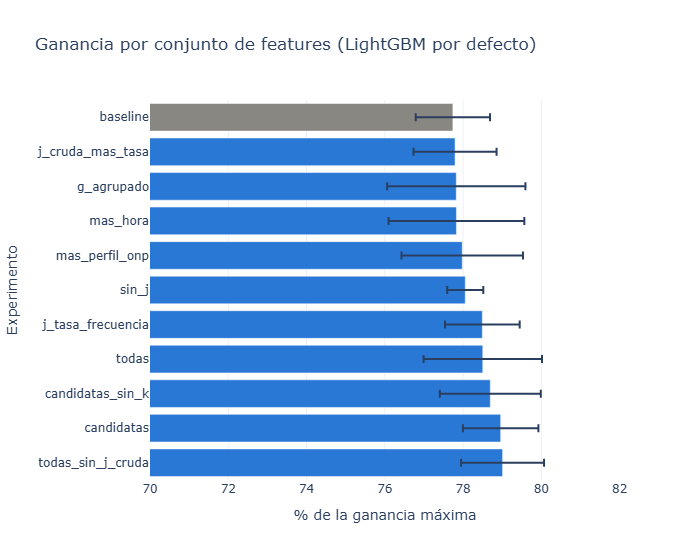

In [10]:
# Ganancia de cada conjunto de features
graficar_ganancia(comparacion_features, 'baseline', 'Ganancia por conjunto de features (LightGBM por defecto)').show()

**💡 Hallazgos**

- **La `j` cruda perjudica al modelo.** Con solo quitarla (`sin_j`), el AUC-ROC sube de 0,872 a 0,887. Esto confirma lo que sugerían el baseline y el notebook 03: LightGBM memoriza las 8.324 categorías en train y eso no generaliza. Mientras la `j` cruda esté presente, el AUC queda en ~0,872 aunque se agreguen su tasa y su frecuencia (`j_cruda_mas_tasa`, `todas`).
- **Reemplazar `j` por su tasa de fraude y su frecuencia** (`j_tasa_frecuencia`) mejora la ganancia en 0,75 puntos y lo hace **en los 5 folds**. Es el cambio individual más importante.
- **`candidatas` es el mejor conjunto: 79,0% de la ganancia máxima**, +1,2 puntos sobre el baseline en los 5 folds, con AUC-ROC de 0,889 y AUC-PR de 0,467 (frente a 0,436). Recupera el 42,5% de la ganancia que se pierde por fraude al aprobar todo, contra el 39,2% del baseline.
- Por separado, `perfil_onp` (+0,24), `hora` (+0,09) y `g_agrupado` (+0,09) aportan poco y no mejoran en todos los folds. A pesar de ser la variable con más señal individual en el notebook 03, `perfil_onp` casi no suma: LightGBM ya aprende la interacción entre `o`, `n` y `p` por su cuenta.
- **Las demás features nuevas no suman sobre las candidatas.** `todas_sin_j_cruda` agrega las 13 restantes (actividad reciente, flags, ratios, monto relativo, etc.) y llega a 79,0%: el mismo AUC-ROC y AUC-PR que `candidatas`, y mejor solo en 3 de los 5 folds. Lo que perjudicaba a `todas` era la `j` cruda, no el resto de las features.
- Quitar `k` no mejora (78,7% frente a 79,0%): la diferencia está dentro de la variación entre folds, así que `k` no molesta aunque no aporte.
- El umbral óptimo de `candidatas` baja a 0,16, por debajo del teórico de 0,20. Con la tasa de `j` como feature, las probabilidades del modelo parecen algo menos calibradas. Habrá que revisarlo después del tuning.
- Se elige **`candidatas`** como conjunto de features para comparar los demás modelos. Rinde igual que `todas_sin_j_cruda` con 19 variables en lugar de 33, así que es más simple de mantener y de explicar.

## **🤖 Comparación de modelos**

Con el conjunto `candidatas` fijo, se comparan cinco modelos con sus **parámetros por defecto**, para que la diferencia refleje el algoritmo y no el ajuste:

| Modelo | Manejo de categóricas y nulos |
|---|---|
| **LightGBM** | Nativo para ambos (es el run `candidatas` de la sección anterior) |
| **XGBoost** | Categóricas nativas (`enable_categorical`) y nulos nativos |
| **CatBoost** | Categóricas con *target statistics* ordenados, pensados para evitar la filtración de la etiqueta |
| **Random Forest** | Categóricas codificadas como enteros; nulos nativos de scikit-learn |
| **Regresión logística** | Imputación por mediana con indicador de nulo, normalización por cuantiles y one-hot de las categorías con al menos 100 transacciones |

La referencia de la comparación fold a fold es LightGBM.

In [11]:
# Un run de MLflow por modelo; LightGBM reutiliza el run de candidatas
modelos_comparados = ['xgboost', 'catboost', 'random_forest', 'regresion_logistica']

resultados_modelos = {'lightgbm': resultados['candidatas']}
for nombre_modelo in modelos_comparados:
    resultados_modelos[nombre_modelo] = run_experiment(
        datos, f'candidatas_{nombre_modelo}', candidatas, nombre_modelo, rate_columns=['j'], tags={'etapa': 'modelos'},
        description=DESCRIPCIONES_RUNS[f'candidatas_{nombre_modelo}'],
    )

In [12]:
# Comparación fold a fold contra LightGBM
comparacion_modelos = comparar_experimentos(resultados_modelos, 'lightgbm')
comparacion_modelos.sort_values('ganancia_pct_maxima', ascending=False)

,ganancia_pct_maxima,desvio,diferencia_vs_referencia,folds_mejores,auc_roc,auc_pr,umbral
experimento,,,,,,,
lightgbm,78.960,0.964,0.000,0,0.889,0.467,0.16
catboost,78.755,0.941,-0.204,2,0.890,0.476,0.16
random_forest,78.752,1.216,-0.207,2,0.864,0.446,0.24
xgboost,77.261,1.311,-1.699,1,0.879,0.442,0.20
regresion_logistica,77.108,0.822,-1.851,0,0.847,0.382,0.18


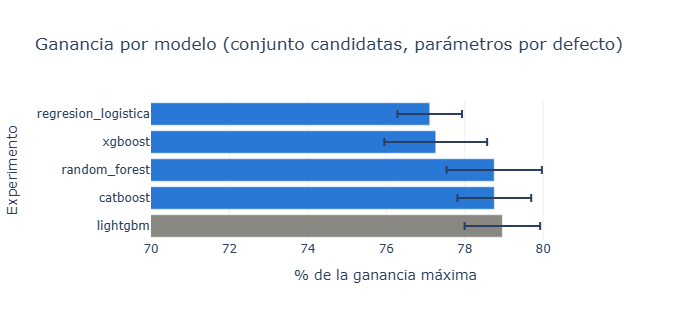

In [13]:
# Ganancia de cada modelo
graficar_ganancia(comparacion_modelos, 'lightgbm', 'Ganancia por modelo (conjunto candidatas, parámetros por defecto)').show()

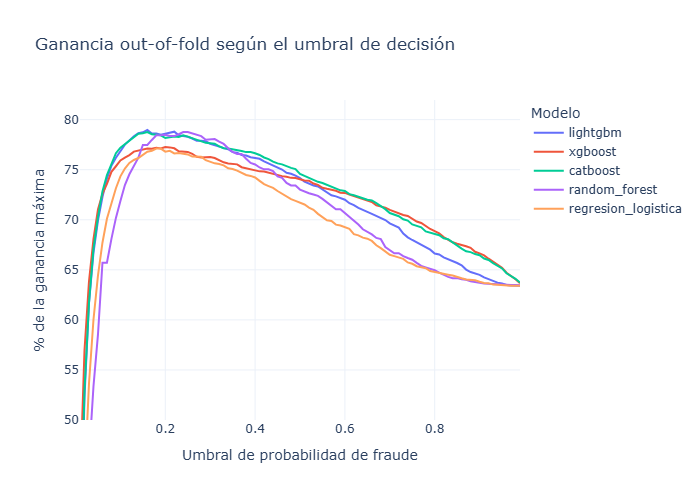

In [14]:
# Curva de ganancia out-of-fold de cada modelo según el umbral, en % de la ganancia máxima
ganancia_maxima = (PROFIT_MARGIN * datos.loc[datos['fraude'] == 0, 'monto']).sum()
curvas_modelos = pd.concat(
    [
        profit_curve(datos['fraude'], datos['monto'], resultado.oof_probability).assign(modelo=nombre_modelo)
        for nombre_modelo, resultado in resultados_modelos.items()
    ],
    ignore_index=True,
).assign(ganancia_pct_maxima=lambda curvas: curvas['ganancia'] / ganancia_maxima * 100)

fig = px.line(
    curvas_modelos,
    x='umbral',
    y='ganancia_pct_maxima',
    color='modelo',
    labels={'umbral': 'Umbral de probabilidad de fraude', 'ganancia_pct_maxima': '% de la ganancia máxima', 'modelo': 'Modelo'},
    title='Ganancia out-of-fold según el umbral de decisión',
)
fig.update_yaxes(range=[50, curvas_modelos['ganancia_pct_maxima'].max() + 3])
fig.show()

**💡 Hallazgos**

- **LightGBM tiene la mayor ganancia (79,0%)**, pero CatBoost (78,8%) y Random Forest (78,8%) quedan a solo 0,2 puntos. Esa diferencia es menor que el desvío entre folds (~1 punto), y cada uno supera a LightGBM en 2 de los 5 folds. Los tres están **técnicamente empatados**.
- **CatBoost tiene el mejor ranking** (AUC-ROC 0,890 y AUC-PR 0,476), pero tardó **~11 minutos** por CV, frente a ~6 segundos de LightGBM: unas 100 veces más. Con ese costo, una búsqueda de hiperparámetros con decenas de pruebas no es viable en este entorno.
- **Random Forest logra la misma ganancia con un AUC bastante menor** (0,864). La ganancia no depende de ordenar bien todas las transacciones, sino de acertar en la zona de decisión y en los montos altos, así que dos modelos con distinto AUC pueden rendir parecido en el negocio.
- **XGBoost queda 1,7 puntos abajo** (77,3%) y solo supera a LightGBM en 1 fold. Con sus valores por defecto (tasa de aprendizaje de 0,3, más agresiva que la de LightGBM) probablemente sobreajusta, así que es el que más podría mejorar con ajuste.
- **La regresión logística llega a 77,1%**, casi lo mismo que el baseline de LightGBM con las variables originales (77,7%). Con buenas features, incluso un modelo lineal captura la mayor parte de la señal. Es la opción más interpretable si eso llegara a pesar más que el último punto de ganancia.
- Se elige **LightGBM** para la búsqueda de hiperparámetros: tiene la mayor ganancia, es el más rápido y permite correr muchas pruebas con Optuna.

## **🎛️ Búsqueda de hiperparámetros**

Optuna busca los hiperparámetros de LightGBM que **maximizan la ganancia out-of-fold media**, con el conjunto `candidatas` y los mismos folds. Cada prueba queda registrada en MLflow como un run anidado dentro de `optuna_lightgbm`.

- La primera prueba son los **parámetros por defecto**, así que la búsqueda parte del resultado ya conocido.
- El espacio de búsqueda cubre la complejidad de los árboles (`num_leaves`, `min_child_samples`), el ritmo de aprendizaje (`learning_rate`, `n_estimators`), el submuestreo de filas y columnas y la regularización.
- Elegir hiperparámetros con los mismos folds con los que se evalúa **sobreestima la mejora**. Por eso, al final, los parámetros elegidos se vuelven a evaluar con **folds nuevos**, generados con otra semilla.

In [15]:
# Parámetros por defecto de LightGBM, para usarlos como primera prueba
PARAMETROS_DEFECTO = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'min_child_samples': 20,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'reg_alpha': 0.001,
    'reg_lambda': 0.001,
}


def objetivo(prueba):
    """Ganancia out-of-fold media de LightGBM con los hiperparámetros propuestos por Optuna."""
    parametros = {
        'n_estimators': prueba.suggest_int('n_estimators', 100, 1500, log=True),
        'learning_rate': prueba.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': prueba.suggest_int('num_leaves', 8, 256, log=True),
        'min_child_samples': prueba.suggest_int('min_child_samples', 10, 500, log=True),
        'subsample': prueba.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': prueba.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': prueba.suggest_float('reg_alpha', 0.001, 10, log=True),
        'reg_lambda': prueba.suggest_float('reg_lambda', 0.001, 10, log=True),
    }
    resultado = run_experiment(
        datos, f'prueba_{prueba.number}', candidatas, 'lightgbm', parametros,
        rate_columns=['j'], tags={'etapa': 'tuning'}, nested=True,
    )
    return resultado.summary['ganancia_pct_maxima_media']

In [16]:
# Búsqueda bayesiana (TPE); todas las pruebas quedan dentro del run padre optuna_lightgbm
estudio = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
estudio.enqueue_trial(PARAMETROS_DEFECTO)

with mlflow.start_run(run_name='optuna_lightgbm'):
    mlflow.set_tags({'etapa': 'tuning', 'modelo': 'lightgbm', DESCRIPTION_TAG: DESCRIPCIONES_RUNS['optuna_lightgbm']})
    estudio.optimize(objetivo, n_trials=NUMERO_PRUEBAS)
    mlflow.log_params(estudio.best_params)
    mlflow.log_metric('mejor_ganancia_pct_maxima_media', estudio.best_value)

print(f'Mejor prueba: {estudio.best_trial.number} — {estudio.best_value:.3f}% de la ganancia máxima')
estudio.best_params

Mejor prueba: 40 — 79.675% de la ganancia máxima


{'n_estimators': 481,
 'learning_rate': 0.019385512410777697,
 'num_leaves': 172,
 'min_child_samples': 262,
 'subsample': 0.9601477375704716,
 'colsample_bytree': 0.9604079184475345,
 'reg_alpha': 1.608317898022548,
 'reg_lambda': 3.025159385030446}

In [17]:
# Las 10 mejores pruebas
(
    estudio.trials_dataframe()
    .sort_values('value', ascending=False)
    .head(10)
    .filter(regex='^(number|value|duration|params_)')
    .rename(columns=lambda columna: columna.replace('params_', ''))
    .round(4)
)

C:\Users\jmart\AppData\Local\Temp\ipykernel_16480\2597737598.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(4)


,number,value,duration,colsample_bytree,learning_rate,min_child_samples,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample
40,40,79.6750,0 days 00:01:15.091479,0.9604,0.0194,262,481,172,1.6083,3.0252,0.9601
22,22,79.5773,0 days 00:01:35.356920,0.8400,0.0119,109,602,111,1.0036,0.0011,0.8723
45,45,79.5527,0 days 00:01:09.477126,0.8799,0.0153,247,429,192,0.2939,3.1833,0.8999
39,39,79.5429,0 days 00:01:11.603289,0.8505,0.0216,168,440,207,0.1558,0.0438,0.9709
38,38,79.4800,0 days 00:01:24.929960,0.9009,0.0146,210,522,198,0.9324,0.0225,0.9796
49,49,79.4693,0 days 00:01:13.857225,0.9420,0.0120,216,484,165,0.4075,1.1286,0.8684
7,7,79.4591,0 days 00:01:43.638767,0.9264,0.0174,205,439,230,0.2464,4.8696,0.9697
13,13,79.4387,0 days 00:03:57.691569,0.9890,0.0172,178,723,173,1.0895,0.0147,0.9805
12,12,79.4317,0 days 00:01:45.960507,0.8169,0.0116,106,785,105,0.0937,0.0072,0.8531
46,46,79.4298,0 days 00:01:27.820467,0.8784,0.0169,307,501,223,0.2375,1.8421,0.9518


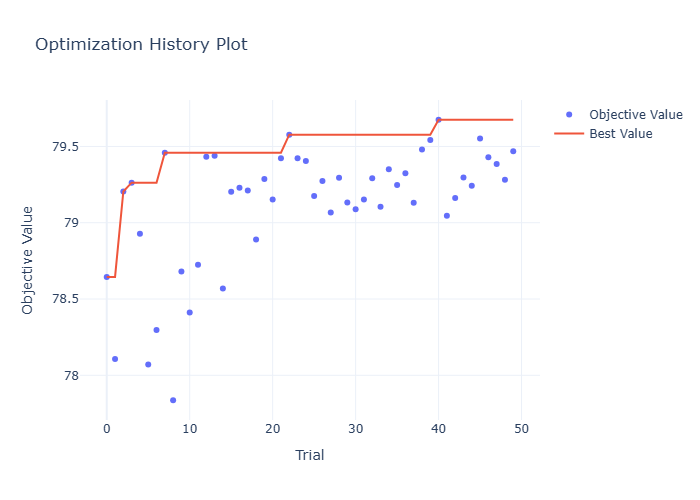

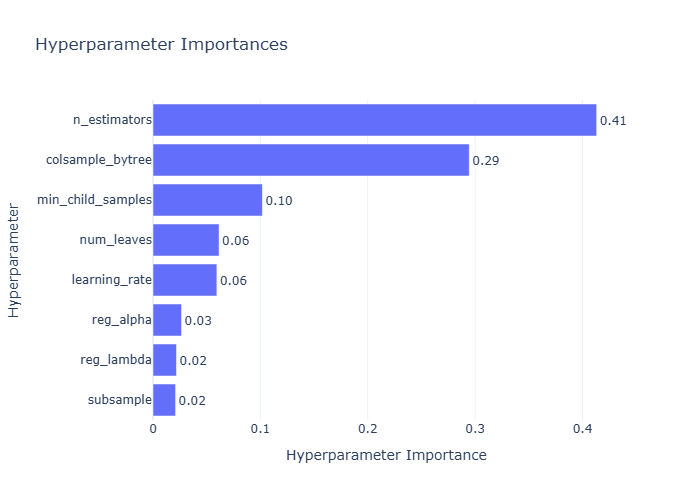

In [18]:
# Evolución de la búsqueda e importancia de cada hiperparámetro
plot_optimization_history(estudio).show()
plot_param_importances(estudio).show()

**💡 Hallazgos**

- La mejor prueba (la 40) llega a **79,7% de la ganancia máxima** sobre los folds de la búsqueda, 0,7 puntos más que LightGBM por defecto (79,0%). Pero 39 de las 50 pruebas superan el 79%: hay una **zona amplia de configuraciones equivalentes**, no un óptimo puntual.
- Las mejores configuraciones comparten un patrón: **tasa de aprendizaje baja** (0,012–0,022) compensada con más árboles (430–790), **hojas grandes** (`num_leaves` de 105 a 230) que exigen **muchos casos por hoja** (`min_child_samples` de 100 a 310) y casi todas las columnas en cada árbol (`colsample_bytree` de 0,82 a 0,99). Es decir, árboles más complejos que aprenden despacio, sin bajar a hojas tan chicas que permitan memorizar.
- La cantidad de árboles (41%) y la fracción de columnas por árbol (29%) explican la mayor parte de la variación de la ganancia. La regularización (`reg_alpha`, `reg_lambda`) y el submuestreo de filas casi no influyen (menos del 3% cada uno).
- ⚠️ La métrica es **ruidosa**: la prueba 0, con los parámetros por defecto más una regularización mínima (prácticamente el mismo modelo), dio 78,6%, contra 79,0% del run `candidatas`. Cambios triviales mueven la ganancia ~0,3 puntos, porque cambian el umbral elegido. Parte de la mejora de la búsqueda puede ser ese ruido, y por eso hace falta la validación con folds nuevos.

## **✅ Validación del tuning con folds nuevos**

Para medir la mejora real, LightGBM con los parámetros por defecto y con los parámetros elegidos se evalúan sobre **folds nuevos** (semilla 7), que no intervinieron en la búsqueda. También se revisa la **calibración** de las probabilidades: si el modelo está bien calibrado, su umbral óptimo debería acercarse al teórico de 0,20.

In [19]:
# LightGBM por defecto vs. con los parámetros elegidos, sobre folds que Optuna no vio
mejores_parametros = {**estudio.best_params, 'subsample_freq': 1}
folds_nuevos = make_folds(datos['fraude'], seed=SEMILLA_VALIDACION)

resultados_validacion = {
    'lightgbm_defecto': run_experiment(
        datos, 'validacion_lightgbm_defecto', candidatas, 'lightgbm',
        rate_columns=['j'], tags={'etapa': 'validacion_tuning'}, folds=folds_nuevos,
        description=DESCRIPCIONES_RUNS['validacion_lightgbm_defecto'],
    ),
    'lightgbm_tuneado': run_experiment(
        datos, 'validacion_lightgbm_tuneado', candidatas, 'lightgbm', mejores_parametros,
        rate_columns=['j'], tags={'etapa': 'validacion_tuning'}, folds=folds_nuevos,
        description=DESCRIPCIONES_RUNS['validacion_lightgbm_tuneado'],
    ),
}
comparar_experimentos(resultados_validacion, 'lightgbm_defecto')

,ganancia_pct_maxima,desvio,diferencia_vs_referencia,folds_mejores,auc_roc,auc_pr,umbral
experimento,,,,,,,
lightgbm_defecto,78.493,1.151,0.000,0,0.889,0.465,0.18
lightgbm_tuneado,78.880,1.436,0.387,4,0.890,0.474,0.15


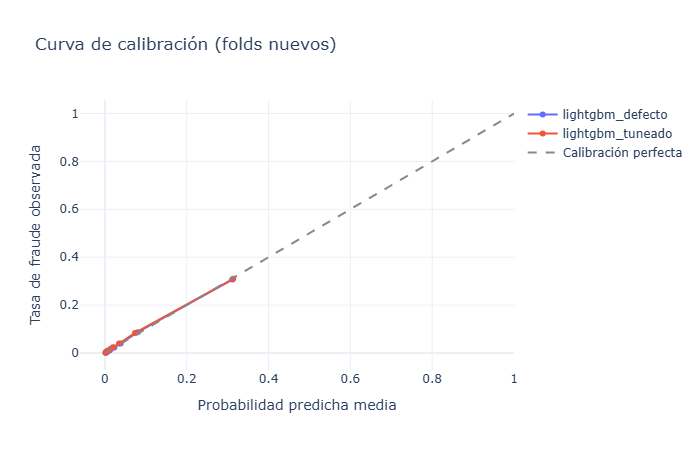

In [20]:
# Curva de calibración: probabilidad predicha media vs. tasa de fraude observada, por decil de probabilidad
fig = go.Figure()
for nombre, resultado in resultados_validacion.items():
    tasa_observada, probabilidad_media = calibration_curve(
        datos['fraude'], resultado.oof_probability, n_bins=10, strategy='quantile'
    )
    fig.add_trace(go.Scatter(x=probabilidad_media, y=tasa_observada, mode='lines+markers', name=nombre))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Calibración perfecta', line={'dash': 'dash', 'color': COLOR_REFERENCIA}))
fig.update_layout(
    title='Curva de calibración (folds nuevos)',
    xaxis_title='Probabilidad predicha media',
    yaxis_title='Tasa de fraude observada',
    height=450,
)
fig.show()

In [21]:
# Ganancia con el umbral teórico (0,20) frente al umbral óptimo, para medir cuánto cuesta no ajustar el umbral
UMBRAL_TEORICO = PROFIT_MARGIN / (1 + PROFIT_MARGIN)
ganancia_maxima_total = (PROFIT_MARGIN * datos.loc[datos['fraude'] == 0, 'monto']).sum()

pd.DataFrame([
    {
        'modelo': nombre,
        'umbral_optimo': resultado.threshold,
        'ganancia_umbral_optimo': profit_curve(datos['fraude'], datos['monto'], resultado.oof_probability, [resultado.threshold])['ganancia'].iloc[0] / ganancia_maxima_total * 100,
        'ganancia_umbral_teorico': profit_curve(datos['fraude'], datos['monto'], resultado.oof_probability, [UMBRAL_TEORICO])['ganancia'].iloc[0] / ganancia_maxima_total * 100,
    }
    for nombre, resultado in resultados_validacion.items()
]).set_index('modelo').round(3)

,umbral_optimo,ganancia_umbral_optimo,ganancia_umbral_teorico
modelo,,,
lightgbm_defecto,0.18,78.484,78.269
lightgbm_tuneado,0.15,78.869,78.251


In [22]:
# Calibración en la franja donde se decide (0,15–0,20), por conteo y ponderada por monto: la ganancia pesa cada error por su monto
modelo_tuneado = resultados_validacion['lightgbm_tuneado']
calibracion_por_monto(datos, modelo_tuneado.oof_probability, 0.15, 0.20)

,transacciones,predicho,observado,predicho_por_monto,observado_por_monto
franja completa,2975.0,0.173,0.169,0.173,0.238
< 100,2563.0,0.173,0.160,0.173,0.165
100–300,300.0,0.174,0.210,0.173,0.214
≥ 300,112.0,0.174,0.250,0.173,0.332


In [23]:
# Bootstrap de la diferencia de ganancia entre el umbral elegido (0,15) y el teórico (0,20): ¿es ruido?
bootstrap_diferencia_umbrales(datos, modelo_tuneado.oof_probability, 0.15, 0.20, REMUESTRAS_BOOTSTRAP, SEED)

diferencia_media      0.613
ic95_inferior        -0.149
ic95_superior         1.472
prob_primero_mejor    0.936
dtype: float64

**💡 Hallazgos**

- Con folds nuevos, el modelo tuneado llega a **78,9%** frente a **78,5%** del modelo por defecto: **+0,4 puntos, mejor en 4 de los 5 folds**. Cerca de la mitad de los +0,7 de la búsqueda era optimismo por elegir y evaluar con los mismos folds. La mejora es modesta pero consistente, y también se ve en el AUC-PR (0,474 frente a 0,465). Que 0,4 puntos cuenten aunque la ganancia varíe ±1 entre folds se debe a que la comparación es **pareada**: ambos modelos se evalúan en los mismos folds, y la diferencia se mide fold a fold. Siguen siendo los mismos datos de la búsqueda con otra partición, así que el optimismo se reduce, pero no desaparece.
- Con los folds nuevos, el modelo por defecto baja de 79,0% a 78,5%: la partición en sí mueve el resultado ~0,5 puntos. Las cifras de ganancia deben leerse con un margen de ±1 punto.
- **Los dos modelos están bien calibrados**: en cada decil, la probabilidad predicha media coincide con la tasa de fraude observada (en el decil más alto, 0,31 predicho frente a 0,31 observado). El modelo tuneado subestima levemente en los deciles medios (0,008 frente a 0,011), una diferencia despreciable.
- Aun así, **el umbral óptimo (0,15) queda por debajo del teórico (0,20), y la causa es la calibración en los montos altos.** La regla `p < 0,20` no depende del monto: con probabilidades calibradas transacción a transacción, 0,20 sería el óptimo aunque los fraudes sean más caros en promedio. En la franja 0,15–0,20 el modelo está calibrado por conteo (0,173 predicho frente a 0,169 observado), pero **no ponderado por monto** (0,238 observado): el fraude real sube a 0,21 entre 100 y 300 de monto y a 0,25 por encima de 300 (0,33 ponderado por monto, sobre 112 transacciones), frente a 0,174 predicho. Como la ganancia pesa cada error por su monto, en esa franja conviene rechazar.
- Usar el umbral teórico en lugar del óptimo cuesta 0,2 puntos con el modelo por defecto y 0,6 con el tuneado. Con bootstrap, esos 0,6 puntos tienen un **IC95 de −0,15 a +1,47**, y 0,15 gana en el 94% de las remuestras: una ventaja consistente pero chica, en una zona plana de la curva. Dos formas de que la decisión considere el monto se prueban más abajo: pesos por monto al entrenar y un umbral por tramo de monto.
- **Modelo elegido: LightGBM tuneado** con el conjunto `candidatas` y un umbral de ~0,15. Más abajo (🧹 y 🏁) se quita `perfil_onp`, y el umbral del modelo final pasa a 0,20.

## **💰 Entrenamiento sensible al monto**

El modelo aprende la probabilidad de fraude tratando igual a todas las transacciones, pero la ganancia pesa cada error por su monto: aprobar un fraude de 500 cuesta 100 veces más que uno de 5. Entrenar con **pesos que dependen del monto** hace que el modelo priorice acertar en las transacciones caras.

- `sin_peso`: el LightGBM tuneado de la sección anterior.
- `peso_raiz_monto`: peso proporcional a la raíz del monto. Es un punto intermedio que reduce la influencia de los montos extremos (el máximo es 3.696).
- `peso_monto`: peso proporcional al monto, que replica cómo pesa cada transacción en la ganancia.

Se usan los parámetros tuneados y los folds nuevos, para comparar contra el resultado honesto de la sección anterior. Los pesos se normalizan a media 1. Con pesos, las probabilidades dejan de estar calibradas, así que el umbral se sigue eligiendo con la curva de ganancia.

In [24]:
# Pesos por transacción normalizados a media 1; sin_peso reutiliza el modelo tuneado de la validación
pesos_monto = {
    'peso_raiz_monto': np.sqrt(datos['monto']) / np.sqrt(datos['monto']).mean(),
    'peso_monto': datos['monto'] / datos['monto'].mean(),
}

resultados_monto = {'sin_peso': resultados_validacion['lightgbm_tuneado']}
for nombre, pesos in pesos_monto.items():
    resultados_monto[nombre] = run_experiment(
        datos, f'validacion_lightgbm_tuneado_{nombre}', candidatas, 'lightgbm', mejores_parametros,
        rate_columns=['j'], tags={'etapa': 'peso_monto', 'peso': nombre}, folds=folds_nuevos, weights=pesos,
        description=DESCRIPCIONES_RUNS[f'validacion_lightgbm_tuneado_{nombre}'],
    )
comparar_experimentos(resultados_monto, 'sin_peso')

,ganancia_pct_maxima,desvio,diferencia_vs_referencia,folds_mejores,auc_roc,auc_pr,umbral
experimento,,,,,,,
sin_peso,78.880,1.436,0.000,0,0.890,0.474,0.15
peso_raiz_monto,78.794,1.154,-0.086,3,0.888,0.471,0.18
peso_monto,78.393,0.920,-0.487,2,0.884,0.459,0.14


In [25]:
# Ganancia y % de rechazos por quintil de monto, con el umbral óptimo de cada modelo: dónde se gana o se pierde
quintil_monto = pd.qcut(datos['monto'], 5).rename('quintil de monto')
ganancia_si_aprueba = np.where(datos['fraude'] == 1, -datos['monto'], PROFIT_MARGIN * datos['monto'])

filas = []
for nombre, resultado in resultados_monto.items():
    aprobada = resultado.oof_probability < resultado.threshold
    por_quintil = pd.DataFrame({
        'ganancia': np.where(aprobada, ganancia_si_aprueba, 0),
        'rechazada': ~aprobada,
        'fraude_rechazado': ~aprobada & (datos['fraude'] == 1),
    }).groupby(quintil_monto, observed=True).sum()
    filas.append(por_quintil.assign(modelo=nombre))

ganancia_por_quintil = pd.concat(filas).reset_index()
ganancia_por_quintil.pivot(index='quintil de monto', columns='modelo', values=['ganancia', 'rechazada', 'fraude_rechazado']).round(0)

ganancia                            rechazada  \
modelo           peso_monto peso_raiz_monto  sin_peso peso_monto   
quintil de monto                                                   
(0.019, 7.83]       32296.0         32622.0   32543.0     2040.0   
(7.83, 14.76]       68902.0         69421.0   69232.0     1988.0   
(14.76, 26.84]     127246.0        127895.0  127433.0     2232.0   
(26.84, 48.95]     218726.0        219317.0  218772.0     2355.0   
(48.95, 3696.35]   724948.0        728851.0  731344.0     3356.0   

                                          fraude_rechazado                  \
modelo           peso_raiz_monto sin_peso       peso_monto peso_raiz_monto   
quintil de monto                                                             
(0.019, 7.83]             1264.0   1496.0            674.0           582.0   
(7.83, 14.76]             1422.0   1761.0            675.0           600.0   
(14.76, 26.84]            1640.0   2094.0            736.0           642.0   
(26.84, 48.95]            1784.0   2229.0            808.0           707.0   
(48.95, 3696.35]          2950.0   3720.0           1294.0          1225.0   

                           
modelo           sin_peso  
quintil de monto           
(0.019, 7.83]       618.0  
(7.83, 14.76]       651.0  
(14.76, 26.84]      716.0  
(26.84, 48.95]      783.0  
(48.95, 3696.35]   1366.0

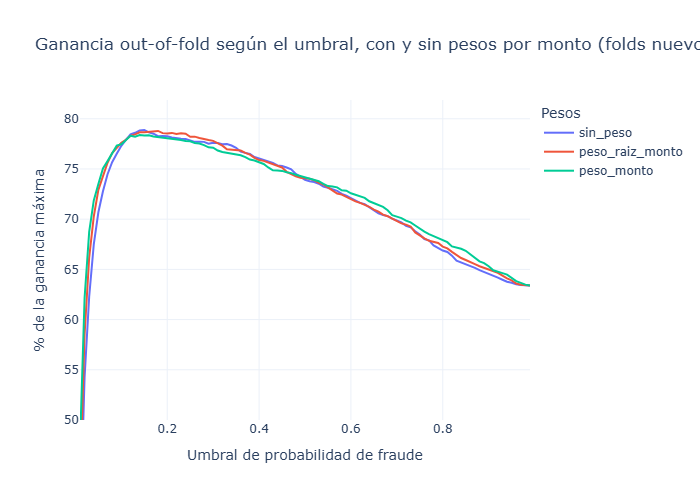

In [26]:
# Curva de ganancia según el umbral para cada esquema de pesos
curvas_monto = pd.concat(
    [
        profit_curve(datos['fraude'], datos['monto'], resultado.oof_probability).assign(modelo=nombre)
        for nombre, resultado in resultados_monto.items()
    ],
    ignore_index=True,
).assign(ganancia_pct_maxima=lambda curvas: curvas['ganancia'] / ganancia_maxima_total * 100)

fig = px.line(
    curvas_monto,
    x='umbral',
    y='ganancia_pct_maxima',
    color='modelo',
    labels={'umbral': 'Umbral de probabilidad de fraude', 'ganancia_pct_maxima': '% de la ganancia máxima', 'modelo': 'Pesos'},
    title='Ganancia out-of-fold según el umbral, con y sin pesos por monto (folds nuevos)',
)
fig.update_yaxes(range=[50, curvas_monto['ganancia_pct_maxima'].max() + 3])
fig.show()

**💡 Hallazgos**

- **Los pesos por monto no mejoran la ganancia.** Con la raíz del monto el resultado es prácticamente igual (78,8% frente a 78,9%, mejor en 3 de 5 folds, dentro del ruido). Con el monto directo empeora 0,5 puntos y baja el AUC-PR (0,459 frente a 0,474).
- **La diferencia se decide en el quintil de montos más altos**, que concentra más de la mitad de la ganancia. Ahí, el modelo con peso por monto rechaza menos transacciones (3.356 frente a 3.720) y detecta menos fraudes (1.294 frente a 1.366), así que gana menos (725 mil frente a 731 mil). En los quintiles bajos, en cambio, rechaza más.
- La explicación es que el monto va de 0,02 a 3.696: con pesos proporcionales al monto, unas pocas transacciones caras dominan el entrenamiento, y el modelo aprende con **mucha más varianza**. La raíz suaviza ese efecto, pero no alcanza para mejorar.
- `monto` ya es una feature, así que el modelo tiene la información para aprender el riesgo de las transacciones caras. Los pesos cambian qué errores se priorizan, pero no agregan información, y con tan pocas transacciones caras amplifican el ruido.
- Se mantiene el **modelo sin pesos**. La subestimación del riesgo en montos altos queda compensada por el umbral de 0,15.

## **🧹 Variables de poco aporte**

Al agregarlas, `hora` aportó +0,09 puntos y `perfil_onp` +0,24, sin mejorar en todos los folds, y en el notebook 05 desordenar `hora` no reduce la ganancia. Se mide qué pasa al **quitarlas** del modelo tuneado, con los folds nuevos: si el resultado no cambia, el modelo puede simplificarse.

In [27]:
# Modelo tuneado sin hora y sin perfil_onp, frente al modelo tuneado completo, sobre los folds nuevos
resultados_simplificacion = {'lightgbm_tuneado': resultados_validacion['lightgbm_tuneado']}
for variable in ['hora', 'perfil_onp']:
    resultados_simplificacion[f'sin_{variable}'] = run_experiment(
        datos, f'validacion_lightgbm_tuneado_sin_{variable}', [columna for columna in candidatas if columna != variable],
        'lightgbm', mejores_parametros, rate_columns=['j'], tags={'etapa': 'simplificacion'}, folds=folds_nuevos,
        description=DESCRIPCIONES_RUNS[f'validacion_lightgbm_tuneado_sin_{variable}'],
    )
comparar_experimentos(resultados_simplificacion, 'lightgbm_tuneado')

,ganancia_pct_maxima,desvio,diferencia_vs_referencia,folds_mejores,auc_roc,auc_pr,umbral
experimento,,,,,,,
lightgbm_tuneado,78.880,1.436,0.000,0,0.890,0.474,0.15
sin_hora,78.617,1.397,-0.263,1,0.888,0.468,0.15
sin_perfil_onp,79.011,1.251,0.131,2,0.890,0.474,0.17


**💡 Hallazgos**

- **`hora` se queda.** Quitarla cuesta 0,26 puntos y el modelo completo es mejor en 4 de los 5 folds, con más AUC-PR (0,474 frente a 0,468). La importancia por permutación negativa del notebook 05 se midió en un solo fold; con los cinco, su aporte es chico pero consistente.
- **`perfil_onp` no aporta con el modelo tuneado.** Sin ella la ganancia es 79,0% (+0,13, mejor en solo 2 de 5 folds, mismo AUC-PR): la diferencia es ruido. LightGBM ya combina `o`, `n` y `p` por su cuenta.
- **Se quita `perfil_onp` del modelo final**: la misma ganancia con un modelo más simple. Desde aquí, el modelo final usa `features_finales` (las `candidatas` sin `perfil_onp`) con los mismos hiperparámetros: el modelo sin perfil ya se evaluó con ellos en los folds nuevos.

## **🏁 Modelo final y umbral**

El modelo final se valida **tal como va a producción**: el pipeline productivo (`FraudPipeline`, sin `perfil_onp` y con los hiperparámetros tuneados) aprende sus tablas solo con el entrenamiento de cada fold, sobre los folds nuevos. Con esas predicciones se revisa la curva de ganancia, la calibración cerca del umbral y si el umbral anterior (0,15) sigue ganando frente al teórico (0,20), que es el de la política de producción (`THRESHOLD`).

In [28]:
# Modelo final como pipeline productivo, sobre los folds nuevos: las tablas de j y de países se aprenden solo con train
features_finales = [columna for columna in candidatas if columna != 'perfil_onp']
datos_crudos = load_data('../data/raw/dataset.csv')

probabilidad_final = np.zeros(len(datos_crudos))
for indices_train, indices_validacion in folds_nuevos:
    pipeline = FraudPipeline(params=mejores_parametros).fit(datos_crudos.iloc[indices_train])
    probabilidad_final[indices_validacion] = pipeline.predict_proba(datos_crudos.iloc[indices_validacion])

ganancia_por_fold = [
    ganancia_pct_maxima(datos_crudos['fraude'].iloc[indices], datos_crudos['monto'].iloc[indices], probabilidad_final[indices], THRESHOLD)
    for _, indices in folds_nuevos
]
umbral_optimo_final = optimal_threshold(datos_crudos['fraude'], datos_crudos['monto'], probabilidad_final)
print(f'Pipeline final con umbral {THRESHOLD}: {np.mean(ganancia_por_fold):.2f}% ± {np.std(ganancia_por_fold, ddof=1):.2f} '
      f'de la ganancia máxima | umbral óptimo: {umbral_optimo_final:.2f}')

curva_final = profit_curve(datos_crudos['fraude'], datos_crudos['monto'], probabilidad_final, [0.12, 0.15, 0.17, 0.20, 0.25, 0.50])
curva_final.assign(ganancia_pct_maxima=curva_final['ganancia'] / ganancia_maxima_total * 100).set_index('umbral').round(3)

Pipeline final con umbral 0.2: 78.90% ± 1.27 de la ganancia máxima | umbral óptimo: 0.20


,ganancia,ganancia_pct_maxima
umbral,,
0.12,1168148.478,78.121
0.15,1176499.155,78.680
0.17,1179473.008,78.879
0.20,1179709.090,78.894
0.25,1164104.732,77.851
0.50,1108962.028,74.163


In [29]:
# Calibración del modelo final en la franja 0,15–0,20 y diferencia entre el umbral de la política (0,20) y el anterior (0,15)
display(calibracion_por_monto(datos_crudos, probabilidad_final, 0.15, 0.20))
bootstrap_diferencia_umbrales(datos_crudos, probabilidad_final, THRESHOLD, 0.15, REMUESTRAS_BOOTSTRAP, SEED)

,transacciones,predicho,observado,predicho_por_monto,observado_por_monto
franja completa,2933.0,0.173,0.162,0.174,0.186
< 100,2536.0,0.172,0.159,0.172,0.165
100–300,297.0,0.174,0.175,0.174,0.192
≥ 300,100.0,0.176,0.210,0.177,0.207


diferencia_media      0.223
ic95_inferior        -0.327
ic95_superior         0.709
prob_primero_mejor    0.796
dtype: float64

**💡 Hallazgos**

- **Modelo final: 78,9% ± 1,3 de la ganancia máxima con umbral 0,20**, validado como pipeline productivo en los folds nuevos. Es el mismo resultado que con `perfil_onp` (78,9% con 0,15), con una variable menos.
- **Sin `perfil_onp`, el umbral óptimo es 0,20: coincide con el teórico.** La curva es plana entre 0,17 y 0,20 (78,88% y 78,89%); con 0,15 da 78,7%.
- **La calibración en montos altos mejora.** En la franja 0,15–0,20, el fraude observado ponderado por monto baja de 0,238 a 0,186 (0,174 predicho), y por encima de 300 de monto, de 0,33 a 0,21 (100 transacciones).
- El bootstrap no separa 0,20 de 0,15 (+0,22 puntos, IC95 de −0,33 a +0,71). Se usa **0,20** porque es el umbral que se deduce de la matriz de costos y coincide con el óptimo: no hace falta ajustarlo con los datos.

## **⏳ Validación out-of-time**

Toda la selección anterior usó CV aleatoria: la tasa de fraude de `j` de una transacción de marzo puede calcularse con etiquetas de abril, y los hiperparámetros se eligieron con las 150.000 transacciones. Aquí se mide el modelo final **prediciendo el futuro**, con el pipeline productivo (sin `perfil_onp`, umbral de 0,20, y tablas aprendidas solo con el entrenamiento):

1. **Ventana creciente**: para cada una de las tres últimas semanas, se entrena con todo lo anterior y se evalúa esa semana. Se compara contra la predicción de la CV aleatoria **en las mismas filas**, para separar el efecto del tiempo de la dificultad de cada semana.
2. **Holdout sin contaminación**: se repite la búsqueda de Optuna **solo con los datos previos al 15 de abril**, y con los hiperparámetros y el umbral elegidos ahí se evalúa la última semana. Ni el ajuste ni el umbral ven esos datos.

In [30]:
# Ventana creciente: entrenar con el pasado y predecir cada semana, frente a la CV aleatoria en las mismas filas
umbral_final = THRESHOLD

filas = []
for inicio in SEMANAS_EVALUADAS:
    fin = pd.Timestamp(inicio) + pd.Timedelta(days=7)
    pasado = datos_crudos[datos_crudos['fecha'] < inicio]
    semana = datos_crudos[(datos_crudos['fecha'] >= inicio) & (datos_crudos['fecha'] < fin)]
    probabilidad = FraudPipeline(params=mejores_parametros).fit(pasado).predict_proba(semana)
    probabilidad_cv = probabilidad_final[semana.index]
    filas.append({
        'semana': inicio,
        'transacciones_train': len(pasado),
        'tasa_fraude_semana': semana['fraude'].mean() * 100,
        'temporal': ganancia_pct_maxima(semana['fraude'], semana['monto'], probabilidad, umbral_final),
        'cv_aleatoria': ganancia_pct_maxima(semana['fraude'], semana['monto'], probabilidad_cv, umbral_final),
        'temporal_umbral_015': ganancia_pct_maxima(semana['fraude'], semana['monto'], probabilidad, 0.15),
        'aprobar_todo': ganancia_pct_maxima(semana['fraude'], semana['monto'], np.zeros(len(semana)), umbral_final),
    })

ventana_creciente = pd.DataFrame(filas).set_index('semana')
ventana_creciente['diferencia_vs_cv'] = ventana_creciente['temporal'] - ventana_creciente['cv_aleatoria']
ventana_creciente.round(2)

,transacciones_train,tasa_fraude_semana,temporal,cv_aleatoria,temporal_umbral_015,aprobar_todo,diferencia_vs_cv
semana,,,,,,,
2020-04-01,76961,5.64,73.72,73.65,75.30,54.54,0.07
2020-04-08,97243,5.22,77.11,78.12,77.64,59.43,-1.02
2020-04-15,121014,4.27,79.46,79.85,80.51,67.14,-0.39


In [31]:
# Búsqueda de Optuna repetida solo con el pasado (antes de la última semana), con el mismo espacio y número de pruebas
inicio_ultima_semana = SEMANAS_EVALUADAS[-1]
datos_pasado = build_features(datos_crudos[datos_crudos['fecha'] < inicio_ultima_semana]).reset_index(drop=True)


def objetivo_pasado(prueba):
    """Ganancia out-of-fold media con los datos previos a la última semana; guarda el umbral elegido."""
    parametros = {
        'n_estimators': prueba.suggest_int('n_estimators', 100, 1500, log=True),
        'learning_rate': prueba.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': prueba.suggest_int('num_leaves', 8, 256, log=True),
        'min_child_samples': prueba.suggest_int('min_child_samples', 10, 500, log=True),
        'subsample': prueba.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': prueba.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': prueba.suggest_float('reg_alpha', 0.001, 10, log=True),
        'reg_lambda': prueba.suggest_float('reg_lambda', 0.001, 10, log=True),
    }
    resultado = run_experiment(
        datos_pasado, f'prueba_pasado_{prueba.number}', features_finales, 'lightgbm', parametros,
        rate_columns=['j'], tags={'etapa': 'tuning_pasado'}, nested=True,
    )
    prueba.set_user_attr('umbral', resultado.threshold)
    return resultado.summary['ganancia_pct_maxima_media']


estudio_pasado = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
estudio_pasado.enqueue_trial(PARAMETROS_DEFECTO)

with mlflow.start_run(run_name='optuna_lightgbm_pasado'):
    mlflow.set_tags({'etapa': 'tuning_pasado', 'modelo': 'lightgbm', DESCRIPTION_TAG: DESCRIPCIONES_RUNS['optuna_lightgbm_pasado']})
    estudio_pasado.optimize(objetivo_pasado, n_trials=NUMERO_PRUEBAS)
    mlflow.log_params(estudio_pasado.best_params)
    mlflow.log_metric('mejor_ganancia_pct_maxima_media', estudio_pasado.best_value)

print(f'Mejor prueba: {estudio_pasado.best_trial.number} — {estudio_pasado.best_value:.3f}% de la ganancia máxima')
estudio_pasado.best_params

Mejor prueba: 14 — 79.397% de la ganancia máxima


{'n_estimators': 454,
 'learning_rate': 0.03217097180288465,
 'num_leaves': 15,
 'min_child_samples': 313,
 'subsample': 0.7401379767904024,
 'colsample_bytree': 0.40642338979636466,
 'reg_alpha': 0.004725735867074931,
 'reg_lambda': 0.0014700147782939364}

In [32]:
# Última semana: parámetros y umbral elegidos solo con el pasado, frente a los por defecto y a los del modelo final
ultima_semana = datos_crudos[datos_crudos['fecha'] >= inicio_ultima_semana]
pasado = datos_crudos[datos_crudos['fecha'] < inicio_ultima_semana]
configuraciones = {
    'tuneado_solo_pasado': ({**estudio_pasado.best_params, 'subsample_freq': 1}, estudio_pasado.best_trial.user_attrs['umbral']),
    'defecto': (PARAMETROS_DEFECTO, estudio_pasado.trials[0].user_attrs['umbral']),
    'modelo_final': (mejores_parametros, umbral_final),
}

filas = []
probabilidades_ultima_semana = {}
for nombre, (parametros, umbral) in configuraciones.items():
    probabilidad = FraudPipeline(params=parametros).fit(pasado).predict_proba(ultima_semana)
    probabilidades_ultima_semana[nombre] = probabilidad
    filas.append({
        'configuracion': nombre,
        'umbral': umbral,
        'ganancia_pct_maxima': ganancia_pct_maxima(ultima_semana['fraude'], ultima_semana['monto'], probabilidad, umbral),
        'ganancia_umbral_020': ganancia_pct_maxima(ultima_semana['fraude'], ultima_semana['monto'], probabilidad, 0.20),
    })

pd.DataFrame(filas).set_index('configuracion').round(3)

,umbral,ganancia_pct_maxima,ganancia_umbral_020
configuracion,,,
tuneado_solo_pasado,0.19,80.035,80.582
defecto,0.20,78.869,78.869
modelo_final,0.20,79.458,79.458


**💡 Hallazgos**

- **Prediciendo el futuro, el modelo final pierde poco.** Entrenando solo con el pasado y con umbral 0,20, las tres últimas semanas dan **73,7%, 77,1% y 79,5%**, entre −1,0 y +0,1 puntos frente a la CV aleatoria en las mismas filas (−0,4 en promedio). La tasa de `j` calculada solo con el pasado no se degrada.
- La ganancia varía más **entre semanas** (de 73,7% a 79,5%) que entre formas de validar: cada semana tiene su propia dificultad (el fraude pasa de 5,6% a 4,3%, y aprobar todo, de 54,5% a 67,1%).
- **En el tiempo, un umbral más bajo habría ganado.** Con 0,15, las tres semanas dan 75,3%, 77,6% y 80,5%: entre +0,5 y +1,6 puntos sobre 0,20. Al predecir el futuro, el modelo parece subestimar el riesgo en la franja de decisión, algo que la CV aleatoria no muestra. Se mantiene 0,20, porque elegir el umbral con estas mismas semanas sería usar la evaluación para decidir; pero en producción el umbral debe **recalibrarse con etiquetas recientes** y monitorearse.
- **Elegir los hiperparámetros con todos los datos no infló el resultado.** Con Optuna repetido solo con el pasado (mejor prueba: 79,4% en su CV) y el umbral elegido ahí (0,19), la última semana da **80,0%**, frente a 79,5% del modelo final y 78,9% de LightGBM por defecto.

## **🎚️ Umbral por monto y por país**

La regla `p < 0,20` no depende del monto: si el modelo estuviera bien calibrado en cada transacción, un único umbral sería óptimo. Si en cambio subestima el riesgo en algún segmento, un **umbral por segmento** puede ganar más. Se prueban dos: por **tramo de monto** y por **país** (Brasil, Argentina y el resto). Para no elegir y evaluar con los mismos datos, los umbrales se eligen con predicciones out-of-fold **del pasado** y se evalúan en la **última semana**, con el modelo tuneado solo con el pasado.

In [33]:
# Predicciones out-of-fold del pasado con los parámetros elegidos solo con el pasado, para elegir los umbrales
parametros_pasado = {**estudio_pasado.best_params, 'subsample_freq': 1}
validacion_pasado = run_experiment(
    datos_pasado, 'validacion_lightgbm_tuneado_pasado', features_finales, 'lightgbm', parametros_pasado,
    rate_columns=['j'], tags={'etapa': 'holdout_temporal'},
    description=DESCRIPCIONES_RUNS['validacion_lightgbm_tuneado_pasado'],
)


def pais(datos_paises):
    """Brasil, Argentina o el resto."""
    return datos_paises['g'].where(datos_paises['g'].isin(['BR', 'AR']), 'Otros')


segmentaciones = {
    'tramo_monto': lambda datos_segmento: pd.cut(datos_segmento['monto'], TRAMOS_MONTO, right=False, labels=ETIQUETAS_TRAMOS).astype(str),
    'pais': pais,
}
umbral_unico = estudio_pasado.best_trial.user_attrs['umbral']
probabilidad_ultima_semana = probabilidades_ultima_semana['tuneado_solo_pasado']

filas = [{
    'politica': 'umbral_unico', 'umbrales': {'todos': umbral_unico},
    'ganancia_ultima_semana': ganancia_pct_maxima(ultima_semana['fraude'], ultima_semana['monto'], probabilidad_ultima_semana, umbral_unico),
}]
for nombre, segmentar in segmentaciones.items():
    segmento_pasado = segmentar(datos_pasado)
    umbrales = {
        segmento: optimal_threshold(
            datos_pasado.loc[segmento_pasado == segmento, 'fraude'],
            datos_pasado.loc[segmento_pasado == segmento, 'monto'],
            validacion_pasado.oof_probability[(segmento_pasado == segmento).to_numpy()],
        )
        for segmento in segmento_pasado.unique()
    }
    umbral_por_fila = segmentar(ultima_semana).map(umbrales).to_numpy()
    filas.append({
        'politica': f'umbral_por_{nombre}', 'umbrales': umbrales,
        'ganancia_ultima_semana': ganancia_pct_maxima(ultima_semana['fraude'], ultima_semana['monto'], probabilidad_ultima_semana, umbral_por_fila),
    })

politicas = pd.DataFrame(filas).set_index('politica')
politicas['diferencia_vs_unico'] = politicas['ganancia_ultima_semana'] - politicas.loc['umbral_unico', 'ganancia_ultima_semana']
politicas.round(3)

,umbrales,ganancia_ultima_semana,diferencia_vs_unico
politica,,,
umbral_unico,{'todos': 0.19},80.035,0.000
umbral_por_tramo_monto,"{'< 100': 0.22, '100–300': 0.18000000000000002...",80.599,0.564
umbral_por_pais,"{'AR': 0.19, 'BR': 0.19, 'Otros': 0.23}",80.025,-0.010


**💡 Hallazgos**

- **Por país, el umbral no cambia nada.** Elegidos con el pasado, quedan iguales o cerca del único (0,19 para Argentina y Brasil, 0,23 para el resto), y la ganancia de la última semana cambia −0,01 puntos.
- **Por tramo de monto, el umbral es más estricto en los montos medios** (0,18 entre 100 y 300, frente a 0,22 por debajo de 100), y la última semana mejora 0,56 puntos. Sobre una sola semana, esa diferencia está dentro del ruido (±1,2 puntos en muestras de 30.000 transacciones), pero apunta en la misma dirección que la validación out-of-time: en los montos altos conviene ser más estricto.
- Se mantiene el **umbral único**. Un umbral por tramo de monto es el primer candidato a probar en producción, con más semanas de etiquetas.